# Inferencija na `svi_clanci.csv` — stav portala po temama

Ovaj notebook koristi **iste modele i konvencije** kao `evaluation_logreg_bertic_ensemble.ipynb`
(LogReg + BERTić + ensemble soft-vote), ali radi **čistu predikciju** na neoznačenom skupu
od 300k+ članaka i agregira rezultate **po portalu**.

Za svaku temu radi se:
1. **binary** (`mentioned` / `not_mentioned`) na svim člancima,
2. **stance** (`against` / `neutral` / `for`) **samo na člancima koje je binary označio kao `mentioned`**
   (ovo drastično smanjuje broj BERTić forward-prolaza).

Izlazi:
- `predikcije_svi_clanci.csv` — predikcija po članku (sve teme),
- `portal_stance_long.csv` + `portal_tabele.xlsx` — tabela stava po portalu i temi (+ sheet po portalu),
- plotovi: scatter tema-vs-tema po portalu, heatmap mention-rate, bar-plotovi net-stava.

## 1. Konfiguracija

In [4]:
!pip install transformers datasets accelerate gdown

  Using cached transformers-5.13.0-py3-none-any.whl.metadata (32 kB)
  Using cached datasets-5.0.0-py3-none-any.whl.metadata (23 kB)
  Using cached accelerate-1.14.0-py3-none-any.whl.metadata (19 kB)
  Using cached gdown-6.1.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached regex-2026.6.28-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (40 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.3 kB)
  Using cached typer-0.26.8-py3-none-any.whl.metadata (15 kB)
  Using cached safetensors-0.8.0-cp310-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.2 kB)
  Using cached click-8.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached hf_xet-1.5.1-cp37-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (4.9 kB)
  Using cached pyarrow-24.0.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (3.0 kB)
  Using cached xxhash-3.8.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86

In [5]:
from pathlib import Path

# ------------------------------------------------------------------
# PROMIJENI OVE PUTANJE
# ------------------------------------------------------------------
DATA_PATH = Path("../svi_clanci.csv")          # 300k+ članaka, neoznačeno

# Mogu biti direktoriji ili ZIP arhive (isto kao u evaluaciji).
LOGREG_BINARY_SOURCE = Path("../models2")
LOGREG_STANCE_SOURCE = Path("../models_stance")
BERT_BINARY_SOURCE   = Path("../bertic_models")
BERT_STANCE_SOURCE   = Path("../bertic_stance_models")

OUTPUT_DIR = Path("inferencija_svi_clanci")
WORK_DIR   = Path("inference_work")          # cache/checkpoint (za restart)

# Koje modele koristiti za predikciju:
#   "ensemble" -> LogReg + BERTić soft-vote (najbolje, ali najsporije)
#   "logreg"   -> samo LogReg (NAJBRŽE; dobra prva iteracija na 300k)
#   "bertic"   -> samo BERTić
INFERENCE_MODEL = "bertic"

# Ime kolone sa portalom u svi_clanci.csv (promijeni ako se zove drugačije).
PORTAL_COLUMN = "PORTAL"

RANDOM_STATE   = 42
BERT_BATCH_SIZE = 16
MAX_LENGTH      = 512

LOGREG_WEIGHT = 0.50
BERT_WEIGHT   = 0.50

# Minimalan broj "mentioned" članaka po (portal, tema) da bi net-stance
# bio prikazan na plotovima (ispod ovoga je previše šuma).
MIN_MENTIONED_FOR_PLOT = 30

# Ako želiš brzi probni prolaz na uzorku, postavi npr. 5000. None = svi članci.
SAMPLE_N = None

TOPICS = [
    "euroatlantske_integracije",
    "negiranje_genocida",
    "gradjanska_vs_konstitutivni",
    "izborna_reforma",
]

BINARY_CLASSES = ["not_mentioned", "mentioned"]
STANCE_CLASSES = ["against", "neutral", "for"]
FOUR_CLASSES   = ["not_mentioned", "against", "neutral", "for"]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WORK_DIR.mkdir(parents=True, exist_ok=True)

assert INFERENCE_MODEL in {"ensemble", "logreg", "bertic"}
assert abs(LOGREG_WEIGHT + BERT_WEIGHT - 1.0) < 1e-9

In [6]:
import matplotlib.pyplot as plt
import pandas as pd


def plot_distribution(
    counts: pd.Series,
    title: str = "Distribution",
    xlabel: str = "Category",
    ylabel: str = "Count",
    horizontal: bool = False,
    show_percentage: bool = True,
    figsize: tuple = (10, 6),
):
    """
    Plot a categorical distribution from a pandas value_counts() Series.

    Example:
        plot_distribution(
            df["portal"].value_counts(),
            title="Article Distribution by Portal"
        )
    """
    counts = counts.dropna()

    if counts.empty:
        raise ValueError("The provided Series is empty.")

    percentages = counts / counts.sum() * 100

    fig, ax = plt.subplots(figsize=figsize)

    if horizontal:
        bars = ax.barh(
            counts.index.astype(str),
            counts.values,
        )

        ax.set_xlabel(ylabel)
        ax.set_ylabel(xlabel)

        for bar, count, percentage in zip(
            bars,
            counts.values,
            percentages.values,
        ):
            label = (
                f"{count:,} ({percentage:.1f}%)"
                if show_percentage
                else f"{count:,}"
            )

            ax.text(
                bar.get_width(),
                bar.get_y() + bar.get_height() / 2,
                f" {label}",
                va="center",
            )

        # Largest category at the top
        ax.invert_yaxis()

    else:
        bars = ax.bar(
            counts.index.astype(str),
            counts.values,
        )

        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.tick_params(axis="x", rotation=30)

        for bar, count, percentage in zip(
            bars,
            counts.values,
            percentages.values,
        ):
            label = (
                f"{count:,}\n({percentage:.1f}%)"
                if show_percentage
                else f"{count:,}"
            )

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                label,
                ha="center",
                va="bottom",
            )

    ax.set_title(title)
    ax.grid(axis="y" if not horizontal else "x", alpha=0.25)

    plt.tight_layout()
    plt.show()
    fig.savefig("portal_dist.png")
    return fig, ax



## 2. Importi i uređaj

In [7]:
import shutil
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from IPython.display import display
from tqdm.auto import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer

warnings.filterwarnings("ignore", category=FutureWarning)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("Inference model:", INFERENCE_MODEL)

Device: cuda
Inference model: bertic


## 3. Pomoćne funkcije (učitavanje modela + predikcija)

Ove funkcije su preuzete 1:1 iz evaluacijskog notebooka da bi se garantirala ista logika
učitavanja modela i usklađivanja klasa.

In [8]:
def prepare_source(source, destination_name):
    source = Path(source)
    if source.is_dir():
        return source
    if source.is_file() and source.suffix.lower() == ".zip":
        destination = WORK_DIR / destination_name
        if destination.exists():
            shutil.rmtree(destination)
        destination.mkdir(parents=True, exist_ok=True)
        shutil.unpack_archive(str(source), str(destination))
        return destination
    raise FileNotFoundError(f"Ne postoji direktorij ili ZIP: {source}")


def find_file_recursively(root, filename):
    matches = list(Path(root).rglob(filename))
    if not matches:
        raise FileNotFoundError(f"Nije pronađen {filename} unutar {root}")
    if len(matches) > 1:
        print(f"Više kandidata za {filename}; koristi se {matches[0]}")
    return matches[0]


def is_hf_model_dir(path):
    path = Path(path)
    weights_exist = any(
        (path / name).exists()
        for name in ["model.safetensors", "pytorch_model.bin"]
    )
    return path.is_dir() and (path / "config.json").exists() and weights_exist


def find_bert_model_dir(root, topic, task):
    root = Path(root)
    if task == "binary":
        candidate_names = [topic, f"bertic_{topic}_final"]
    elif task == "stance":
        candidate_names = [topic, f"bertic_stance_{topic}_final"]
    else:
        raise ValueError(task)

    for name in candidate_names:
        candidate = root / name
        if is_hf_model_dir(candidate):
            return candidate
    for name in candidate_names:
        for candidate in root.rglob(name):
            if is_hf_model_dir(candidate):
                return candidate
    for config_path in root.rglob("config.json"):
        candidate = config_path.parent
        if topic in str(candidate) and is_hf_model_dir(candidate):
            return candidate
    raise FileNotFoundError(
        f"Nije pronađen BERTić {task} model za {topic} unutar {root}"
    )

In [9]:
def normalize_label(label):
    text = str(label).strip()
    aliases = {"not mentioned": "not_mentioned", "not-mentioned": "not_mentioned"}
    return aliases.get(text.lower(), text.lower())


def align_probability_columns(probabilities, source_classes, target_classes,
                              fallback_label_order=None):
    source = [normalize_label(x) for x in source_classes]
    target = [normalize_label(x) for x in target_classes]

    if all(label in source for label in target):
        positions = [source.index(label) for label in target]
        return probabilities[:, positions]

    generic = all(label.startswith("label_") for label in source)
    if generic and fallback_label_order is not None:
        fallback = [normalize_label(x) for x in fallback_label_order]
        mapping = dict(zip(source, fallback))
        mapped_source = [mapping[x] for x in source]
        if all(label in mapped_source for label in target):
            positions = [mapped_source.index(label) for label in target]
            return probabilities[:, positions]

    raise ValueError(
        f"Ne mogu uskladiti klase. source={source_classes}, target={target_classes}"
    )


def sklearn_predict_proba_aligned(model, texts, target_classes):
    if not hasattr(model, "predict_proba"):
        raise TypeError("Model nema predict_proba; ensemble traži vjerovatnoće.")
    probabilities = model.predict_proba(list(texts))
    return align_probability_columns(probabilities, model.classes_, target_classes)


@torch.inference_mode()
def bert_predict_proba_aligned(model, tokenizer, texts, target_classes,
                               fallback_label_order):
    all_probabilities = []
    texts = list(map(str, texts))
    for start in tqdm(range(0, len(texts), BERT_BATCH_SIZE), leave=False):
        batch = texts[start:start + BERT_BATCH_SIZE]
        encoded = tokenizer(batch, truncation=True, padding=True,
                            max_length=MAX_LENGTH, return_tensors="pt")
        encoded = {k: v.to(DEVICE) for k, v in encoded.items()}
        logits = model(**encoded).logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        all_probabilities.append(probs)

    probabilities = np.vstack(all_probabilities) if all_probabilities \
        else np.empty((0, len(target_classes)))

    id2label = model.config.id2label
    source_classes = [
        id2label.get(i, id2label.get(str(i), f"LABEL_{i}"))
        for i in range(probabilities.shape[1])
    ]
    return align_probability_columns(
        probabilities, source_classes, target_classes,
        fallback_label_order=fallback_label_order,
    )


def weighted_soft_vote(logreg_probs, bert_probs):
    probabilities = LOGREG_WEIGHT * logreg_probs + BERT_WEIGHT * bert_probs
    return probabilities / probabilities.sum(axis=1, keepdims=True)


def labels_from_probs(probabilities, classes):
    classes = np.asarray(classes)
    return classes[np.argmax(probabilities, axis=1)]

## 4. Učitavanje i priprema `svi_clanci.csv`

In [10]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset nije pronađen: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print("Učitano redova:", f"{len(df):,}")
print("Kolone:", list(df.columns))

if "SADRZAJ" not in df.columns:
    raise ValueError("Nedostaje kolona 'SADRZAJ'.")
if PORTAL_COLUMN not in df.columns:
    raise ValueError(
        f"Nedostaje kolona portala '{PORTAL_COLUMN}'. "
        f"Postavi PORTAL_COLUMN na tačno ime. Dostupno: {list(df.columns)}"
    )

n_before = len(df)
df = df.dropna(subset=["SADRZAJ"]).reset_index(drop=True)

if "naslov" not in df.columns:
    df["naslov"] = ""

df[PORTAL_COLUMN] = df[PORTAL_COLUMN].fillna("(nepoznato)").astype(str).str.strip()

df["row_id"] = np.arange(len(df))
df["TEXT_BERT"] = (
    df["naslov"].fillna("").astype(str) + ". " + df["SADRZAJ"].fillna("").astype(str)
)

if SAMPLE_N is not None:
    df = df.sample(n=min(SAMPLE_N, len(df)), random_state=RANDOM_STATE)\
           .reset_index(drop=True)
    print(f"UZORAK: radi se na {len(df):,} članaka (SAMPLE_N={SAMPLE_N}).")

print(f"Prije čišćenja: {n_before:,}  |  Nakon čišćenja: {len(df):,}")
print("Broj portala:", df[PORTAL_COLUMN].nunique())
display(df[PORTAL_COLUMN].value_counts().head(20).rename("broj_clanaka").to_frame())

Učitano redova: 305,790
Kolone: ['PORTAL', 'DATUM', 'NASLOV', 'SADRZAJ', 'euroatlantske_integracije_score', 'euroatlantske_integracije_overlap', 'euroatlantske_integracije_matched', 'negiranje_genocida_score', 'negiranje_genocida_overlap', 'negiranje_genocida_matched', 'gradjanska_vs_konstitutivni_score', 'gradjanska_vs_konstitutivni_overlap', 'gradjanska_vs_konstitutivni_matched', 'izborna_reforma_score', 'izborna_reforma_overlap', 'izborna_reforma_matched']
Prije čišćenja: 305,790  |  Nakon čišćenja: 305,790
Broj portala: 6


,broj_clanaka
PORTAL,
Klix.ba,100754
RTRS,93980
Radio Sarajevo,41299
6yka,39075
Dnevni Avaz,22847
STAV,7835


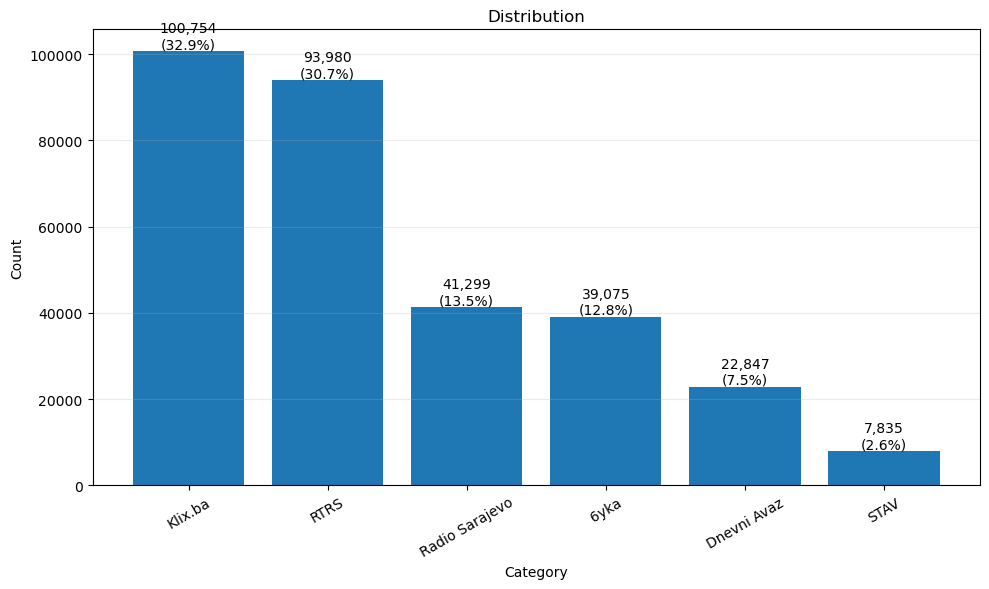

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Distribution'}, xlabel='Category', ylabel='Count'>)

In [11]:
plot_distribution(df["PORTAL"].value_counts())

## 5. Učitavanje modela

In [13]:
logreg_binary_root = prepare_source(LOGREG_BINARY_SOURCE, "logreg_binary")
logreg_stance_root = prepare_source(LOGREG_STANCE_SOURCE, "logreg_stance")
bert_binary_root   = prepare_source(BERT_BINARY_SOURCE, "bert_binary")
bert_stance_root   = prepare_source(BERT_STANCE_SOURCE, "bert_stance")

LOGREG_BINARY_MODELS = {}
LOGREG_STANCE_MODELS = {}
BERT_BINARY_MODELS = {}
BERT_STANCE_MODELS = {}

need_logreg = INFERENCE_MODEL in {"ensemble", "logreg"}
need_bert   = INFERENCE_MODEL in {"ensemble", "bertic"}

for topic in TOPICS:
    if need_logreg:
        LOGREG_BINARY_MODELS[topic] = joblib.load(
            find_file_recursively(logreg_binary_root, f"{topic}__logreg_binary.joblib"))
        LOGREG_STANCE_MODELS[topic] = joblib.load(
            find_file_recursively(logreg_stance_root, f"{topic}__logreg_stance.joblib"))

    if need_bert:
        binary_dir = find_bert_model_dir(bert_binary_root, topic, "binary")
        stance_dir = find_bert_model_dir(bert_stance_root, topic, "stance")
        BERT_BINARY_MODELS[topic] = {
            "tokenizer": AutoTokenizer.from_pretrained(binary_dir),
            "model": AutoModelForSequenceClassification
                .from_pretrained(binary_dir).to(DEVICE).eval(),
        }
        BERT_STANCE_MODELS[topic] = {
            "tokenizer": AutoTokenizer.from_pretrained(stance_dir),
            "model": AutoModelForSequenceClassification
                .from_pretrained(stance_dir).to(DEVICE).eval(),
        }
    print("Učitano:", topic)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Učitano: euroatlantske_integracije


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Učitano: gradjanska_vs_konstitutivni


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Učitano: izborna_reforma


## 6. Predikcija po temi (sa checkpointing-om)

Za svaku temu: prvo binary na svim člancima, pa stance samo na `mentioned` podskupu.
Rezultati po temi se keširaju u `WORK_DIR` (`.npz`) — ako se runtime prekine, ponovno
pokretanje preskače već obrađene teme.

In [14]:
def predict_task_probs(task, topic, texts_logreg, texts_bert, classes):
    """Vrati (probs, per_model) za dati task na datom (pod)skupu tekstova."""
    per_model = {}
    if INFERENCE_MODEL in {"ensemble", "logreg"}:
        lr_model = (LOGREG_BINARY_MODELS if task == "binary" else LOGREG_STANCE_MODELS)[topic]
        per_model["LogReg"] = sklearn_predict_proba_aligned(lr_model, texts_logreg, classes)
    if INFERENCE_MODEL in {"ensemble", "bertic"}:
        bundle = (BERT_BINARY_MODELS if task == "binary" else BERT_STANCE_MODELS)[topic]
        per_model["BERTic"] = bert_predict_proba_aligned(
            bundle["model"], bundle["tokenizer"], texts_bert, classes,
            fallback_label_order=classes)

    if INFERENCE_MODEL == "ensemble":
        probs = weighted_soft_vote(per_model["LogReg"], per_model["BERTic"])
    elif INFERENCE_MODEL == "logreg":
        probs = per_model["LogReg"]
    else:
        probs = per_model["BERTic"]
    return probs


def predict_topic(topic):
    cache = WORK_DIR / f"{topic}__{INFERENCE_MODEL}.npz"
    if cache.exists():
        data = np.load(cache, allow_pickle=True)
        print(f"[cache] {topic}")
        return {k: data[k] for k in data.files}

    n = len(df)
    logreg_text = df["SADRZAJ"].astype(str)     # LogReg: samo SADRZAJ
    bert_text   = df["TEXT_BERT"]               # BERTić: naslov + ". " + SADRZAJ

    # --- BINARY na svim člancima ---
    print(f"[{topic}] binary na {n:,} članaka...")
    bin_probs = predict_task_probs("binary", topic, logreg_text, bert_text, BINARY_CLASSES)
    mentioned_idx = BINARY_CLASSES.index("mentioned")
    p_mentioned = bin_probs[:, mentioned_idx]
    is_mentioned = labels_from_probs(bin_probs, BINARY_CLASSES) == "mentioned"

    # --- STANCE samo na mentioned podskupu ---
    stance_probs = np.full((n, len(STANCE_CLASSES)), np.nan)
    m = np.where(is_mentioned)[0]
    print(f"[{topic}] mentioned={m.size:,} -> stance na tom podskupu...")
    if m.size > 0:
        sp = predict_task_probs(
            "stance", topic,
            logreg_text.iloc[m], bert_text.iloc[m], STANCE_CLASSES)
        stance_probs[m] = sp

    out = {
        "p_mentioned": p_mentioned,
        "is_mentioned": is_mentioned,
        "stance_probs": stance_probs,
    }
    np.savez_compressed(cache, **out)
    return out


TOPIC_RESULTS = {t: predict_topic(t) for t in TOPICS}
print("Gotovo. Teme:", list(TOPIC_RESULTS))

[euroatlantske_integracije] binary na 305,790 članaka...


  0%|          | 0/19112 [00:00<?, ?it/s]

[euroatlantske_integracije] mentioned=73,883 -> stance na tom podskupu...


  0%|          | 0/4618 [00:00<?, ?it/s]

[negiranje_genocida] binary na 305,790 članaka...


...

[izborna_reforma] binary na 305,790 članaka...


  0%|          | 0/19112 [00:00<?, ?it/s]

[izborna_reforma] mentioned=26,432 -> stance na tom podskupu...


  0%|          | 0/1652 [00:00<?, ?it/s]

Gotovo. Teme: ['euroatlantske_integracije', 'negiranje_genocida', 'gradjanska_vs_konstitutivni', 'izborna_reforma']


## 7. Sastavljanje predikcija po članku

In [15]:
pred = df[["row_id", PORTAL_COLUMN, "naslov"]].copy()
if "article_id" in df.columns:
    pred.insert(1, "article_id", df["article_id"].values)
if "datum" in df.columns:
    pred["datum"] = df["datum"].values

for topic in TOPICS:
    r = TOPIC_RESULTS[topic]
    is_m = r["is_mentioned"]
    sp = r["stance_probs"]

    pred[f"{topic}_mentioned"] = np.where(is_m, "mentioned", "not_mentioned")
    pred[f"{topic}_p_mentioned"] = r["p_mentioned"]

    stance_lbl = np.array(["not_mentioned"] * len(df), dtype=object)
    valid = ~np.isnan(sp).any(axis=1)
    stance_lbl[valid] = np.asarray(STANCE_CLASSES)[np.argmax(sp[valid], axis=1)]
    pred[f"{topic}_stance"] = stance_lbl

    for j, cls in enumerate(STANCE_CLASSES):
        pred[f"{topic}_p_{cls}"] = sp[:, j]

    pred[f"{topic}_final"] = np.where(is_m, stance_lbl, "not_mentioned")

pred_path = OUTPUT_DIR / "predikcije_svi_clanci.csv"
pred.to_csv(pred_path, index=False)
print("Snimljeno:", pred_path, "| redova:", f"{len(pred):,}")
display(pred.head(3))

Snimljeno: inferencija_svi_clanci/predikcije_svi_clanci.csv | redova: 305,790


,row_id,PORTAL,naslov,euroatlantske_integracije_mentioned,euroatlantske_integracije_p_mentioned,euroatlantske_integracije_stance,euroatlantske_integracije_p_against,euroatlantske_integracije_p_neutral,euroatlantske_integracije_p_for,euroatlantske_integracije_final,...,gradjanska_vs_konstitutivni_p_neutral,gradjanska_vs_konstitutivni_p_for,gradjanska_vs_konstitutivni_final,izborna_reforma_mentioned,izborna_reforma_p_mentioned,izborna_reforma_stance,izborna_reforma_p_against,izborna_reforma_p_neutral,izborna_reforma_p_for,izborna_reforma_final
0,0,Klix.ba,,not_mentioned,0.012107,not_mentioned,NaN,NaN,NaN,not_mentioned,...,NaN,NaN,not_mentioned,not_mentioned,0.007772,not_mentioned,NaN,NaN,NaN,not_mentioned
1,1,Klix.ba,,not_mentioned,0.011392,not_mentioned,NaN,NaN,NaN,not_mentioned,...,NaN,NaN,not_mentioned,not_mentioned,0.007763,not_mentioned,NaN,NaN,NaN,not_mentioned
2,2,Klix.ba,,not_mentioned,0.016342,not_mentioned,NaN,NaN,NaN,not_mentioned,...,NaN,NaN,not_mentioned,not_mentioned,0.007797,not_mentioned,NaN,NaN,NaN,not_mentioned


## 8. Agregacija po portalu (tabele stava)

Za svaki (portal, tema): koliko članaka, koliko `mentioned`, mention-rate,
raspodjela stava (`for`/`against`/`neutral`) među `mentioned` člancima i
**net_stance = (share_for − share_against) ∈ [−1, 1]**.

In [16]:
def portal_topic_stance_table(pred, topics, portal_col):
    rows = []
    for portal, g in pred.groupby(portal_col):
        n_all = len(g)
        for t in topics:
            ment = g[f"{t}_mentioned"].eq("mentioned")
            n_ment = int(ment.sum())
            sub = g.loc[ment, f"{t}_stance"]
            n_for = int((sub == "for").sum())
            n_ag  = int((sub == "against").sum())
            n_neu = int((sub == "neutral").sum())
            def sh(x):
                return x / n_ment if n_ment else np.nan
            rows.append({
                "portal": portal, "tema": t,
                "n_clanaka": n_all, "n_mentioned": n_ment,
                "mention_rate": n_ment / n_all if n_all else np.nan,
                "n_for": n_for, "n_against": n_ag, "n_neutral": n_neu,
                "share_for": sh(n_for), "share_against": sh(n_ag),
                "share_neutral": sh(n_neu),
                "net_stance": (n_for - n_ag) / n_ment if n_ment else np.nan,
            })
    return pd.DataFrame(rows)


portal_stance = portal_topic_stance_table(pred, TOPICS, PORTAL_COLUMN)
portal_stance = portal_stance.sort_values(["portal", "tema"]).reset_index(drop=True)
portal_stance.to_csv(OUTPUT_DIR / "portal_stance_long.csv", index=False)
display(portal_stance.head(len(TOPICS) * 3))

,portal,tema,n_clanaka,n_mentioned,mention_rate,n_for,n_against,n_neutral,share_for,share_against,share_neutral,net_stance
0,6yka,euroatlantske_integracije,39075,8133,0.208138,2738,2221,3174,0.336653,0.273085,0.390262,0.063568
1,6yka,gradjanska_vs_konstitutivni,39075,8044,0.205861,1722,5541,781,0.214073,0.688836,0.097091,-0.474764
2,6yka,izborna_reforma,39075,3583,0.091695,755,1427,1401,0.210717,0.398270,0.391013,-0.187552
3,6yka,negiranje_genocida,39075,3006,0.076929,1629,815,562,0.541916,0.271124,0.186959,0.270792
4,Dnevni Avaz,euroatlantske_integracije,22847,7271,0.318247,3963,1132,2176,0.545042,0.155687,0.299271,0.389355
5,Dnevni Avaz,gradjanska_vs_konstitutivni,22847,4009,0.175472,1171,2430,408,0.292093,0.606136,0.101771,-0.314043
6,Dnevni Avaz,izborna_reforma,22847,1879,0.082243,586,742,551,0.311868,0.394891,0.293241,-0.083023
7,Dnevni Avaz,negiranje_genocida,22847,2811,0.123036,2062,367,382,0.733547,0.130559,0.135895,0.602988
8,Klix.ba,euroatlantske_integracije,100754,24309,0.241271,11272,3498,9539,0.463697,0.143897,0.392406,0.319799
9,Klix.ba,gradjanska_vs_konstitutivni,100754,18939,0.187973,5962,10235,2742,0.314800,0.540419,0.144781,-0.225619


In [17]:
# Pivot tabele: portal x tema
net_pivot      = portal_stance.pivot(index="portal", columns="tema", values="net_stance")
mention_pivot  = portal_stance.pivot(index="portal", columns="tema", values="mention_rate")
share_for_piv  = portal_stance.pivot(index="portal", columns="tema", values="share_for")
share_ag_piv   = portal_stance.pivot(index="portal", columns="tema", values="share_against")
portal_size    = portal_stance.groupby("portal")["n_clanaka"].first()

print("NET STANCE (for - against) po portalu i temi:")
display(net_pivot.round(3))
print("MENTION RATE po portalu i temi:")
display(mention_pivot.round(3))

NET STANCE (for - against) po portalu i temi:


tema,euroatlantske_integracije,gradjanska_vs_konstitutivni,izborna_reforma,negiranje_genocida
portal,,,,
6yka,0.064,-0.475,-0.188,0.271
Dnevni Avaz,0.389,-0.314,-0.083,0.603
Klix.ba,0.320,-0.226,-0.038,0.679
RTRS,-0.402,-0.961,-0.658,-0.699
Radio Sarajevo,0.411,-0.025,0.027,0.757
STAV,-0.061,-0.284,-0.341,0.579


MENTION RATE po portalu i temi:


tema,euroatlantske_integracije,gradjanska_vs_konstitutivni,izborna_reforma,negiranje_genocida
portal,,,,
6yka,0.208,0.206,0.092,0.077
Dnevni Avaz,0.318,0.175,0.082,0.123
Klix.ba,0.241,0.188,0.096,0.096
RTRS,0.214,0.230,0.063,0.089
Radio Sarajevo,0.279,0.255,0.108,0.175
STAV,0.328,0.384,0.123,0.141


In [18]:
# Excel: long tabela + pivoti + sheet po portalu
with pd.ExcelWriter(OUTPUT_DIR / "portal_tabele.xlsx", engine="openpyxl") as writer:
    portal_stance.to_excel(writer, sheet_name="svi_portali_long", index=False)
    net_pivot.round(4).to_excel(writer, sheet_name="net_stance_pivot")
    mention_pivot.round(4).to_excel(writer, sheet_name="mention_rate_pivot")

    used = set()
    for portal, g in portal_stance.groupby("portal"):
        base = str(portal)[:28] or "portal"
        name, k = base, 1
        while name in used:
            name = f"{base}_{k}"; k += 1
        used.add(name)
        g.drop(columns=["portal"]).to_excel(writer, sheet_name=name, index=False)

print("Snimljeno:", OUTPUT_DIR / "portal_tabele.xlsx")

Snimljeno: inferencija_svi_clanci/portal_tabele.xlsx


## 9. Plotovi

### 9.1 Scatter tema-vs-tema (jedna tačka = jedan portal)
Podrazumijevano: **x = euroatlantske integracije**, **y = negiranje genocida**,
veličina tačke = broj članaka portala. Osi su net-stav (for − against).

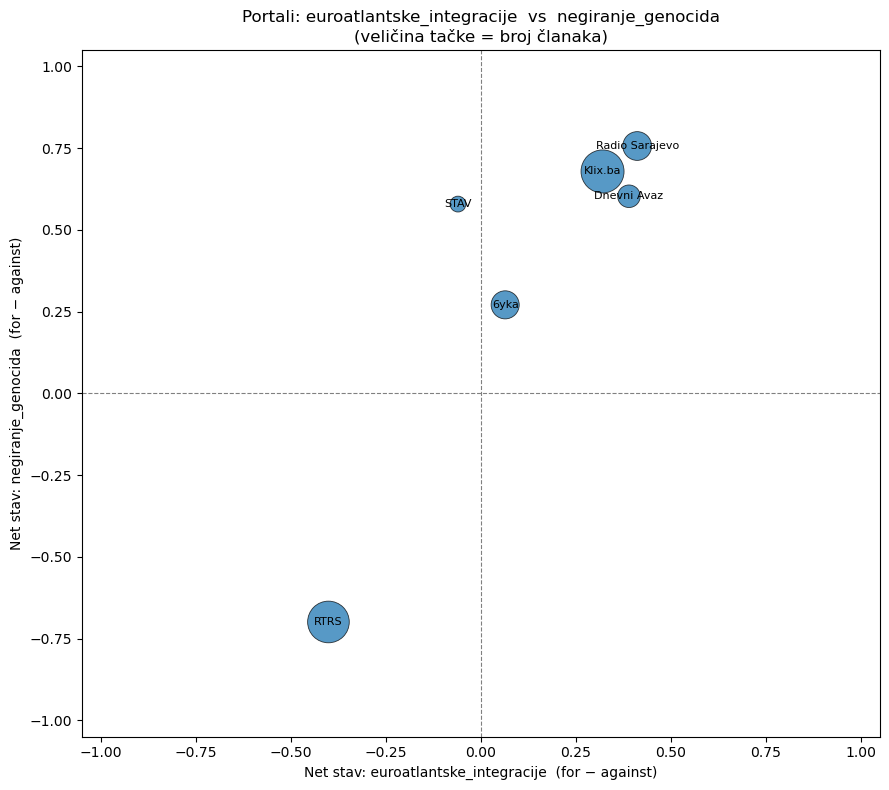

In [19]:
def topic_scatter(net_pivot, portal_size, x_topic, y_topic, path,
                  min_mentioned=MIN_MENTIONED_FOR_PLOT, stance_long=None):
    valid_idx = net_pivot.index
    if stance_long is not None:
        nм = stance_long.pivot(index="portal", columns="tema", values="n_mentioned")
        mask = (nм[x_topic] >= min_mentioned) & (nм[y_topic] >= min_mentioned)
        valid_idx = net_pivot.index[mask.reindex(net_pivot.index).fillna(False).values]

    x = net_pivot.loc[valid_idx, x_topic]
    y = net_pivot.loc[valid_idx, y_topic]
    sizes = portal_size.reindex(valid_idx).astype(float)
    s = (sizes / sizes.max() * 900 + 60) if len(sizes) and sizes.max() > 0 else 120

    fig, ax = plt.subplots(figsize=(9, 8))
    ax.axhline(0, color="grey", lw=0.8, ls="--")
    ax.axvline(0, color="grey", lw=0.8, ls="--")
    ax.scatter(x, y, s=s, alpha=0.75, edgecolor="black", linewidth=0.6)
    for p in valid_idx:
        ax.annotate(str(p), (x[p], y[p]), fontsize=8, ha="center", va="center")
    ax.set_xlabel(f"Net stav: {x_topic}  (for − against)")
    ax.set_ylabel(f"Net stav: {y_topic}  (for − against)")
    ax.set_title(f"Portali: {x_topic}  vs  {y_topic}\n(veličina tačke = broj članaka)")
    lim = 1.05
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    fig.tight_layout(); fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.show(); plt.close(fig)


topic_scatter(net_pivot, portal_size,
              "euroatlantske_integracije", "negiranje_genocida",
              OUTPUT_DIR / "scatter_euroatlantske_vs_genocid.png",
              stance_long=portal_stance)

### 9.2 Svi parovi tema (automatski)

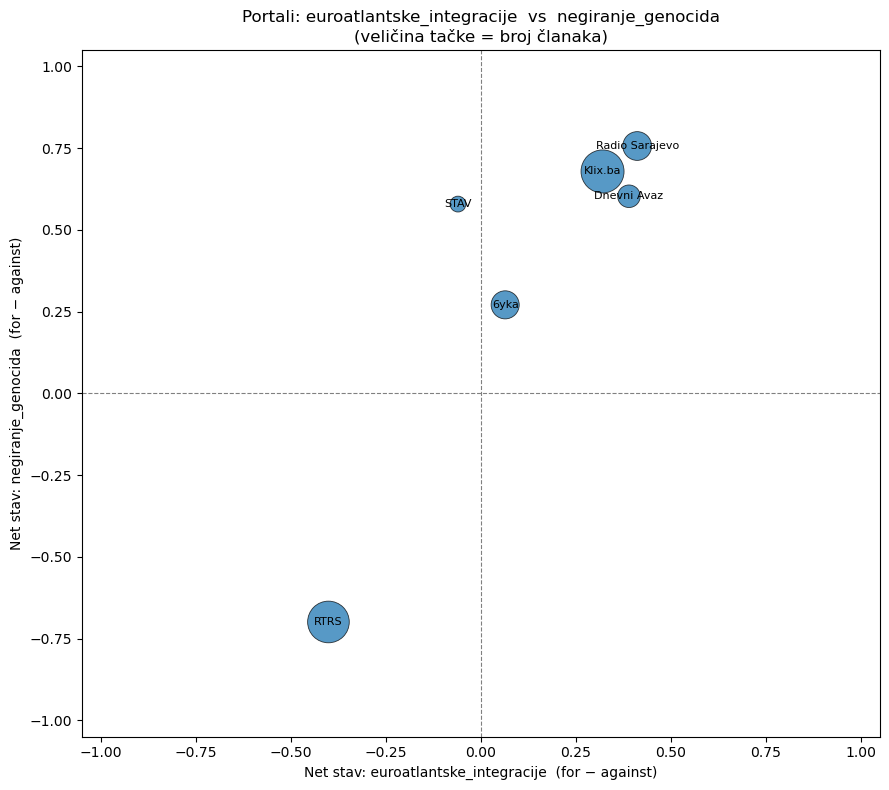

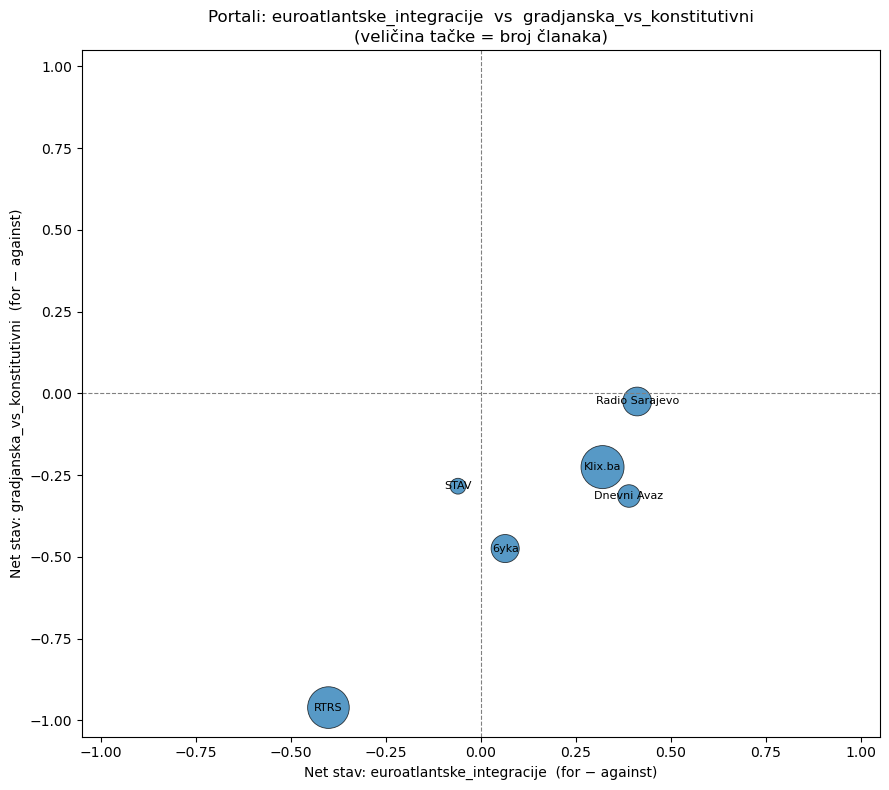

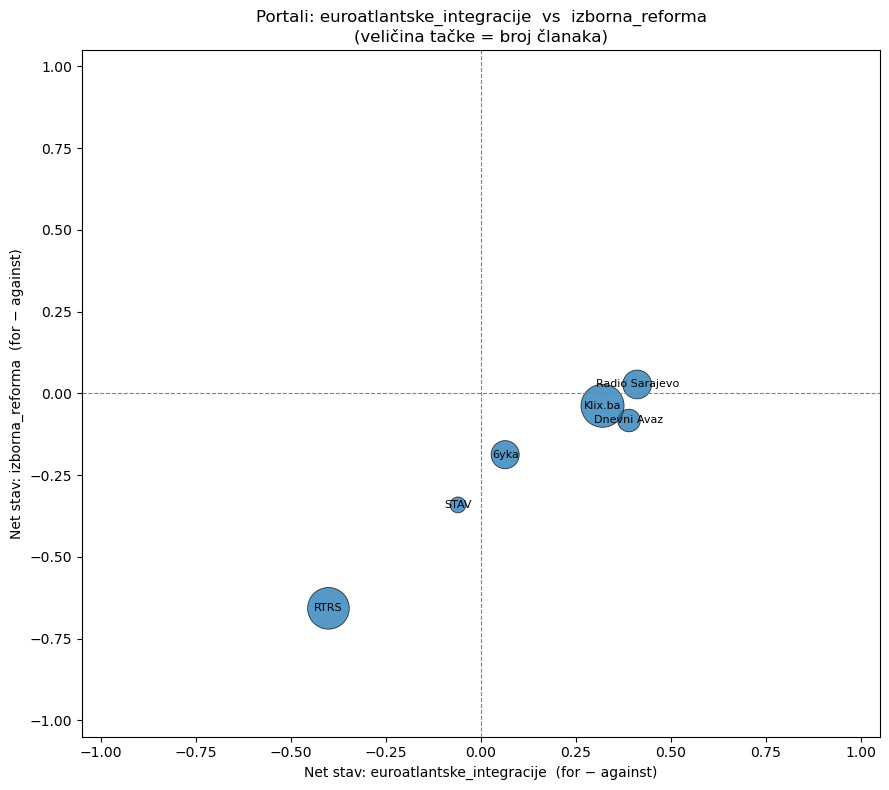

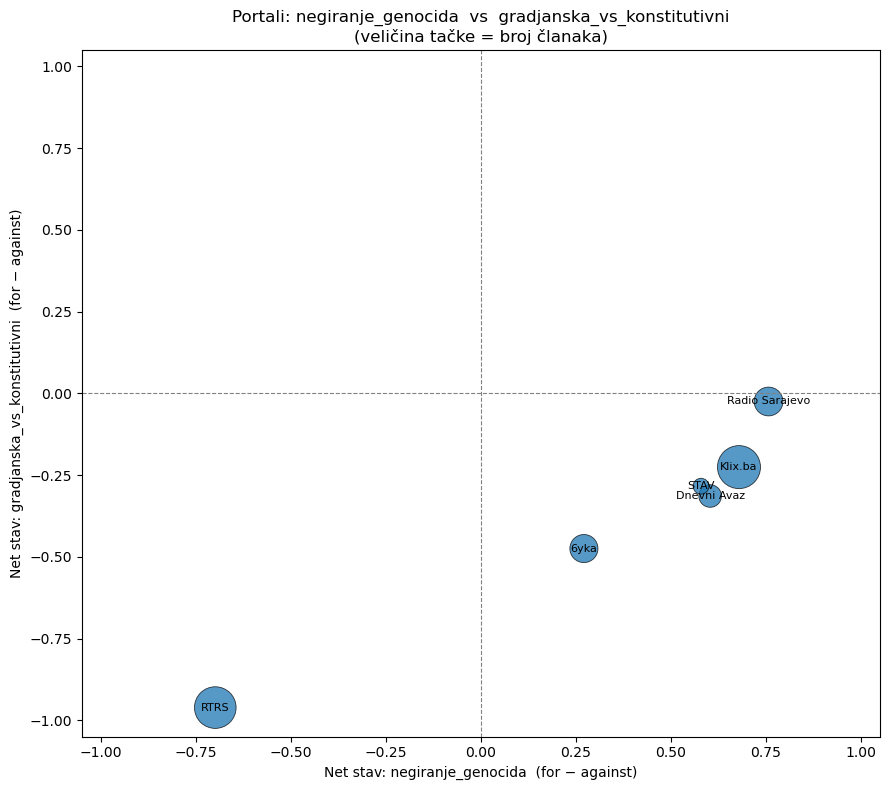

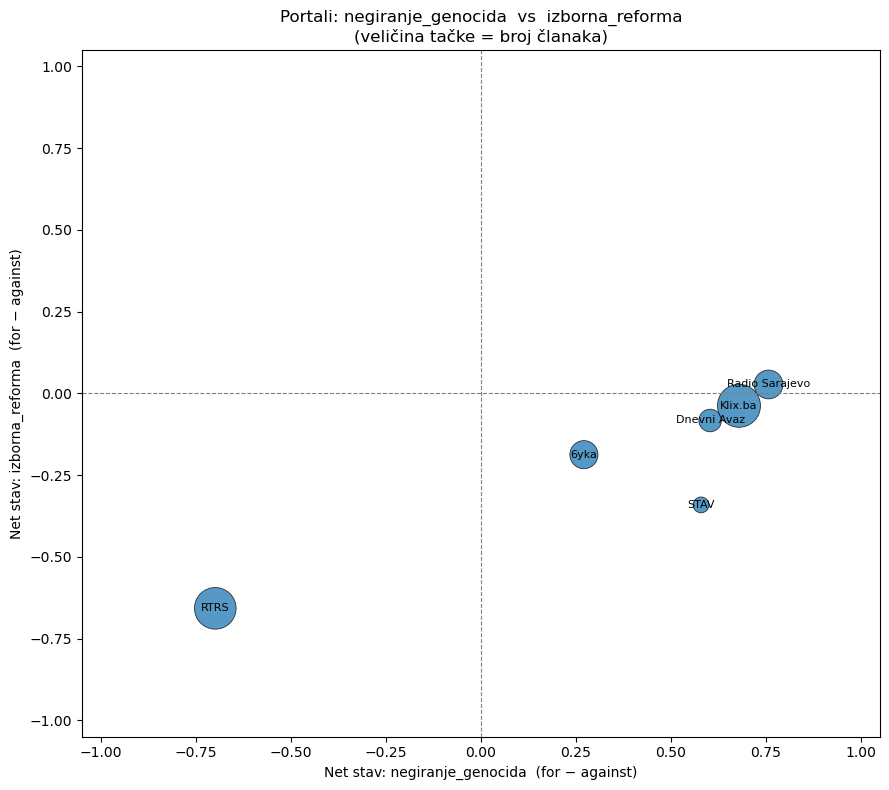

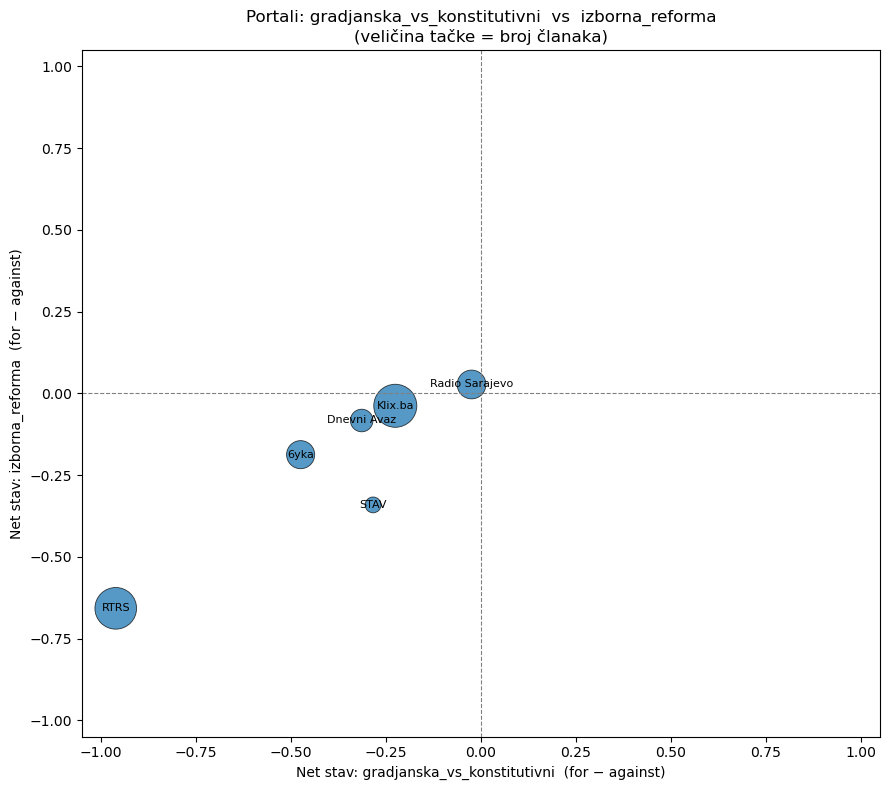

In [20]:
from itertools import combinations

for x_topic, y_topic in combinations(TOPICS, 2):
    fname = OUTPUT_DIR / f"scatter__{x_topic}__vs__{y_topic}.png"
    topic_scatter(net_pivot, portal_size, x_topic, y_topic, fname,
                  stance_long=portal_stance)

### 9.3 Heatmap: mention-rate (koliko koji portal uopšte pokriva temu)

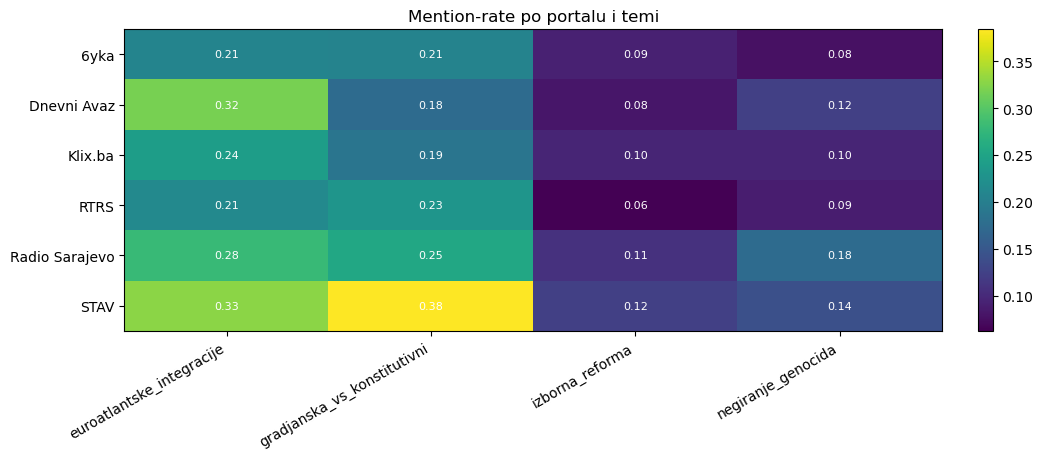

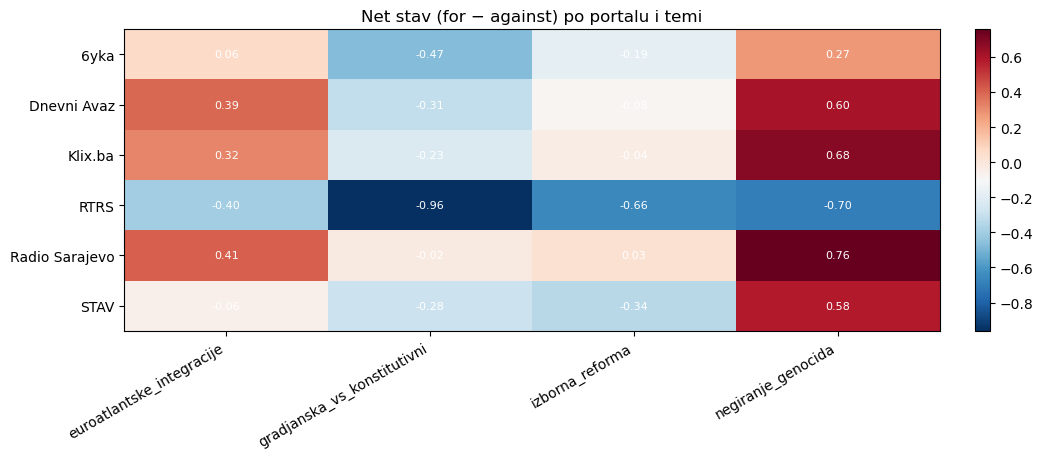

In [21]:
def heatmap(mat, title, path, fmt="{:.2f}", cmap="viridis"):
    mat = mat.dropna(how="all")
    fig, ax = plt.subplots(figsize=(1.9 * mat.shape[1] + 3, 0.45 * mat.shape[0] + 2))
    im = ax.imshow(mat.values, aspect="auto", cmap=cmap)
    ax.set_xticks(range(mat.shape[1]))
    ax.set_xticklabels(mat.columns, rotation=30, ha="right")
    ax.set_yticks(range(mat.shape[0]))
    ax.set_yticklabels(mat.index)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, fmt.format(v), ha="center", va="center",
                        color="white", fontsize=8)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout(); fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.show(); plt.close(fig)


heatmap(mention_pivot, "Mention-rate po portalu i temi",
        OUTPUT_DIR / "heatmap_mention_rate.png")
heatmap(net_pivot, "Net stav (for − against) po portalu i temi",
        OUTPUT_DIR / "heatmap_net_stance.png", cmap="RdBu_r")

### 9.4 Net-stav po portalu za svaku temu (bar-plot)

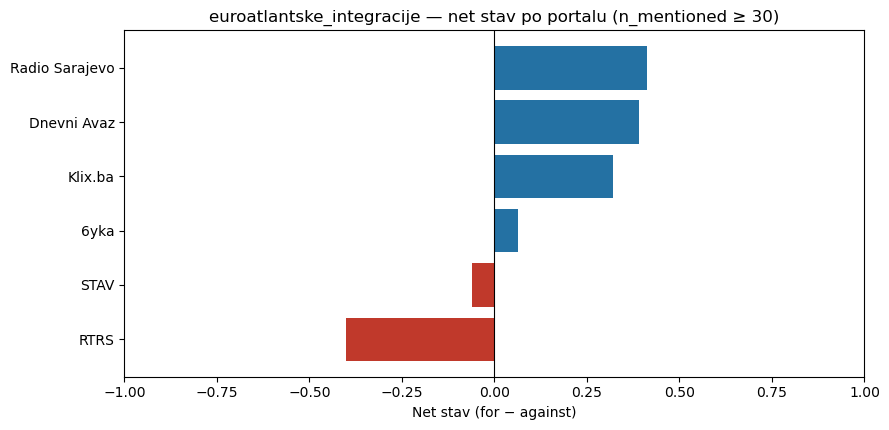

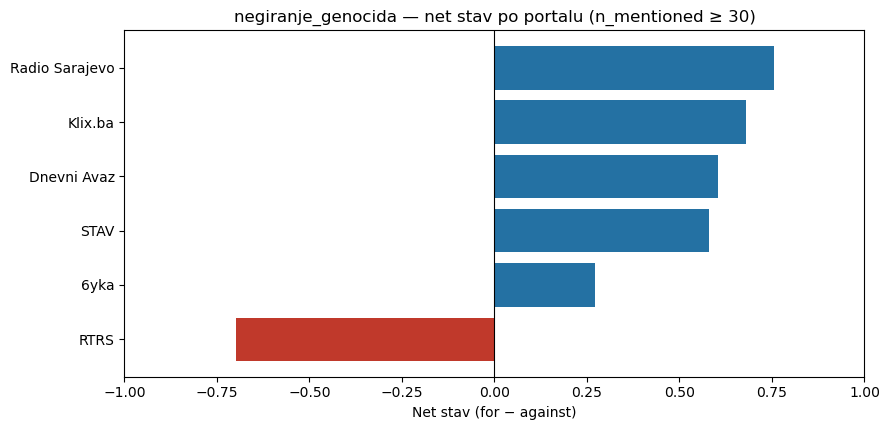

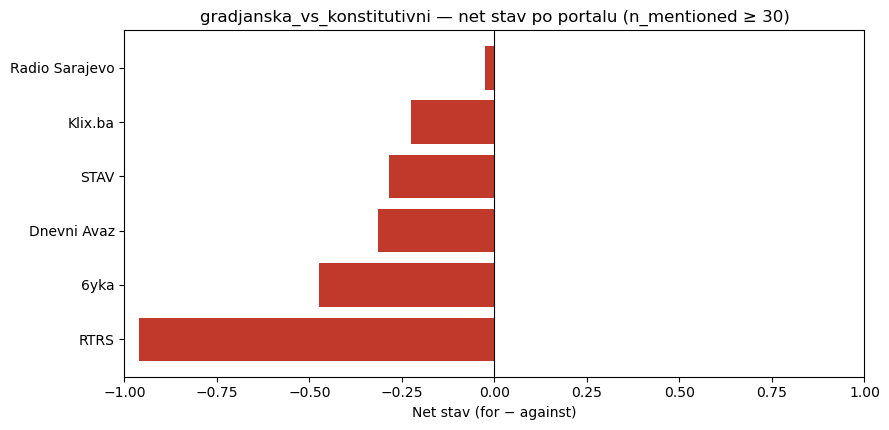

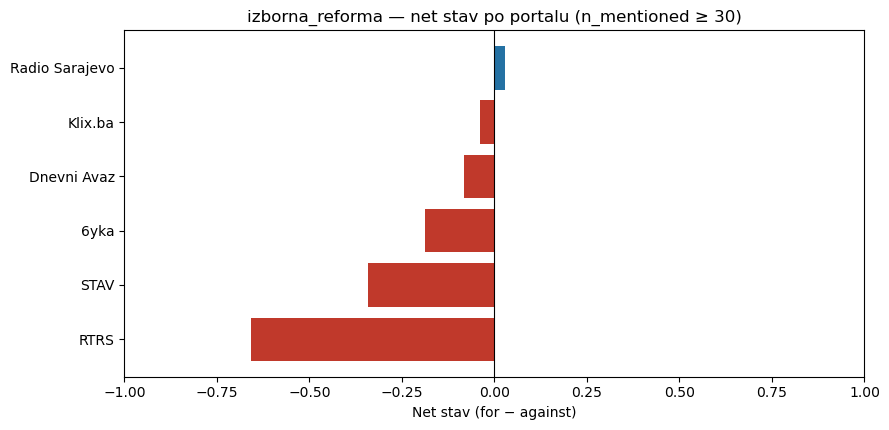

In [22]:
for topic in TOPICS:
    sub = portal_stance[(portal_stance["tema"] == topic) &
                        (portal_stance["n_mentioned"] >= MIN_MENTIONED_FOR_PLOT)]
    sub = sub.sort_values("net_stance")
    if sub.empty:
        print("Nema dovoljno podataka za:", topic); continue
    fig, ax = plt.subplots(figsize=(9, 0.4 * len(sub) + 2))
    colors = ["#c0392b" if v < 0 else "#2471a3" for v in sub["net_stance"]]
    ax.barh(sub["portal"], sub["net_stance"], color=colors)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Net stav (for − against)")
    ax.set_title(f"{topic} — net stav po portalu (n_mentioned ≥ {MIN_MENTIONED_FOR_PLOT})")
    ax.set_xlim(-1, 1)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"bar_net_stance__{topic}.png", dpi=180, bbox_inches="tight")
    plt.show(); plt.close(fig)

## 10. Sažetak izlaza

Sve je snimljeno u `OUTPUT_DIR`:

- `predikcije_svi_clanci.csv` — predikcija po članku (mentioned/stance/vjerovatnoće za sve teme)
- `portal_stance_long.csv` — duga tabela stava po (portal, tema)
- `portal_tabele.xlsx` — long + pivoti + zaseban sheet po portalu
- `scatter_*.png`, `heatmap_*.png`, `bar_net_stance__*.png` — vizualizacije

**Interpretacija net_stance:** vrijednost > 0 znači da među člancima koji spominju temu
prevladava `for`, < 0 da prevladava `against`. Značenje `for`/`against` zavisi od toga kako
je definisan target teme pri treniranju stance modela — provjeri to prije zaključaka.

In [23]:
import os
print("Fajlovi u", OUTPUT_DIR, ":")
for f in sorted(OUTPUT_DIR.rglob("*")):
    if f.is_file():
        print(" ", f.relative_to(OUTPUT_DIR), f"({f.stat().st_size/1024:.0f} KB)")

Fajlovi u inferencija_svi_clanci :
  bar_net_stance__euroatlantske_integracije.png (47 KB)
  bar_net_stance__gradjanska_vs_konstitutivni.png (46 KB)
  bar_net_stance__izborna_reforma.png (45 KB)
  bar_net_stance__negiranje_genocida.png (46 KB)
  heatmap_mention_rate.png (113 KB)
  heatmap_net_stance.png (117 KB)
  portal_stance_long.csv (4 KB)
  portal_tabele.xlsx (16 KB)
  predikcije_svi_clanci.csv (80406 KB)
  scatter__euroatlantske_integracije__vs__gradjanska_vs_konstitutivni.png (108 KB)
  scatter__euroatlantske_integracije__vs__izborna_reforma.png (101 KB)
  scatter__euroatlantske_integracije__vs__negiranje_genocida.png (104 KB)
  scatter__gradjanska_vs_konstitutivni__vs__izborna_reforma.png (101 KB)
  scatter__negiranje_genocida__vs__gradjanska_vs_konstitutivni.png (105 KB)
  scatter__negiranje_genocida__vs__izborna_reforma.png (99 KB)
  scatter_euroatlantske_vs_genocid.png (104 KB)


In [34]:
import subprocess

http_log = open("http_server.log", "w")

http_process = subprocess.Popen(
    ["python3", "-m", "http.server", "8000"],
    stdout=http_log,
    stderr=subprocess.STDOUT,
    start_new_session=True
)

print("HTTP server PID:", http_process.pid)

HTTP server PID: 855


In [35]:
cloudflare_log = open("cloudflared.log", "w")

tunnel_process = subprocess.Popen(
    [
        "./cloudflared",
        "tunnel",
        "--url",
        "http://127.0.0.1:8000",
        "--no-autoupdate"
    ],
    stdout=cloudflare_log,
    stderr=subprocess.STDOUT,
    start_new_session=True
)

print("Cloudflare PID:", tunnel_process.pid)

Cloudflare PID: 857


In [33]:
!nohup python3 -m http.server 8000 > http_server.log 2>&1 &
!nohup ./cloudflared tunnel --url http://127.0.0.1:8000 > cloudflared.log 2>&1 &

OSError: Background processes not supported.